### Installing Required Libraries

In [ ]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn

### Importing the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### To ignore minor warnings

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In [ ]:
df = pd.read_csv('/content/HR_Employee_Attrition.csv')

### Inspecting the Dataset

In [ ]:
print("1. DATASET SHAPE CHECK:")

print(f"Total Rows (Employees): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}")

total_nulls = df.isnull().sum().sum()
print(f"\nTotal Missing / Null Values: {total_nulls}")

print("\n")
print("2. ATTRITION VALUE COUNTS:")

print(df['Attrition'].value_counts())

1. DATASET SHAPE CHECK:
Total Rows (Employees): 1470
Total Columns (Features): 35

Total Missing / Null Values: 0


2. ATTRITION VALUE COUNTS:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


### Removing useless column

In [ ]:
useless_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=useless_cols)

print("FEATURE CLEANING CHECK:")
print(f"Original shape: {df.shape}")
print(f"Columns dropped: {useless_cols}")
print(f"New cleaned shape: {df_clean.shape}")

FEATURE CLEANING CHECK:
Original shape: (1470, 35)
Columns dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New cleaned shape: (1470, 31)


### Turning Attrition into numeric and in total (%)

In [ ]:
df_clean['Attrition_Numeric'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print(df_clean['Attrition_Numeric'])

attrition_rate = df_clean['Attrition_Numeric'].mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition_Numeric, Length: 1470, dtype: int64
Overall Attrition Rate: 16.12%


### Grouping the columns by Attrition Rate

In [ ]:
print("1. ATTRITION RATE BY DEPARTMENT (%)")
dept_attrition = df_clean.groupby('Department')['Attrition_Numeric'].mean() * 100
dept_attrition = dept_attrition.round(2).sort_values(ascending = False)
print(dept_attrition)

print('\n')
print("2. ATTRITION RATE BY OVERTIME STATUS (%)")
overtime_attrition = df_clean.groupby('OverTime')['Attrition_Numeric'].mean() * 100
overtime_attrition = overtime_attrition.round(2).sort_values(ascending = False)
print(overtime_attrition)

print('\n')
print("3. ATTRITION RATE BY JOB ROLE (%)")
jobrole_attrition = df_clean.groupby('JobRole')['Attrition_Numeric'].mean() * 100
jobrole_attrition = jobrole_attrition.round(2).sort_values(ascending = False)
print(jobrole_attrition)

1. ATTRITION RATE BY DEPARTMENT (%)
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Numeric, dtype: float64


2. ATTRITION RATE BY OVERTIME STATUS (%)
OverTime
Yes    30.53
No     10.44
Name: Attrition_Numeric, dtype: float64


3. ATTRITION RATE BY JOB ROLE (%)
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Numeric, dtype: float64


# Comparing Numeric Columns (Stayed vs Left)

In [ ]:
print("AVERAGE METRICS: STAYED ('No') vs LEFT ('Yes')")
print('\n')
numeric_metrics = ['MonthlyIncome', 'Age', 'YearsAtCompany', 'TotalWorkingYears', 'DistanceFromHome']

comparison_table = df_clean.groupby('Attrition')[numeric_metrics].mean().round(1)
print(comparison_table)

AVERAGE METRICS: STAYED ('No') vs LEFT ('Yes')


           MonthlyIncome   Age  YearsAtCompany  TotalWorkingYears  \
Attrition                                                           
No                6832.7  37.6             7.4               11.9   
Yes               4787.1  33.6             5.1                8.2   

           DistanceFromHome  
Attrition                    
No                      8.9  
Yes                    10.6  


# Visualization

### 2x2 grid of 4 Charts

SUCCESS: Saved '01_attrition_overview.png' to project folder!


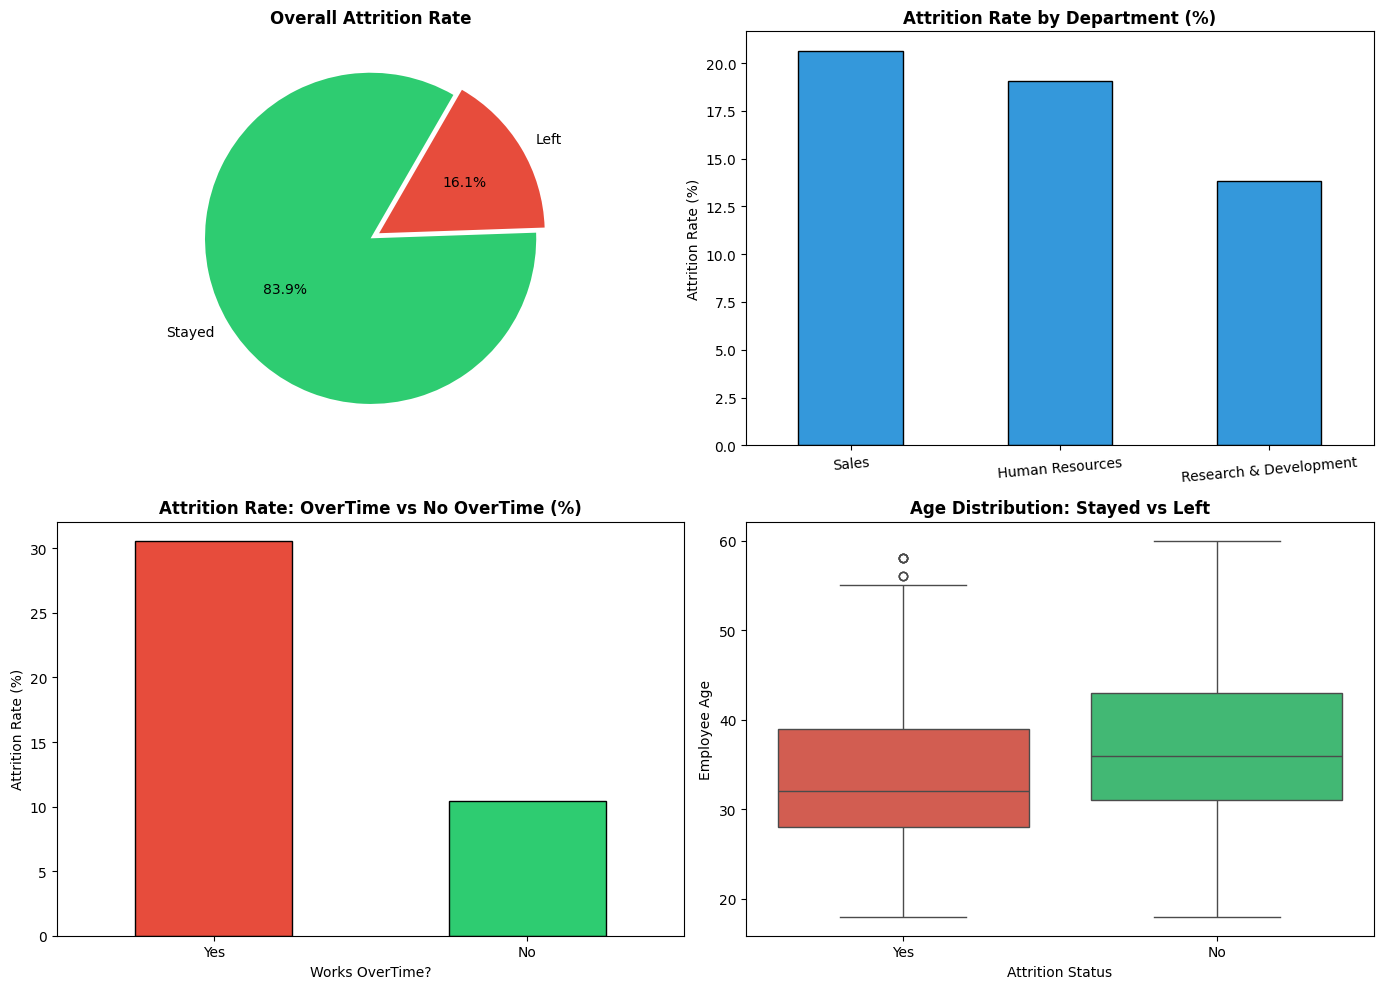

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Charts: 1
attrition_counts = df_clean['Attrition'].value_counts()
axes[0, 0].pie(
    attrition_counts,
    labels=['Stayed', 'Left'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],  # Green for Stayed, Red for Left
    startangle=60,
    explode=(0, 0.06)  # Slightly separates the 'Left' slice for emphasis
)
axes[0, 0].set_title('Overall Attrition Rate', fontsize=12, fontweight='bold')

#Charts: 2
dept_attrition.plot(
    kind='bar',
    ax=axes[0, 1],
    color='#3498db',
    edgecolor='black'
)
axes[0, 1].set_title('Attrition Rate by Department (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Attrition Rate (%)')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=5)  # Rotates department labels slightly for readability

#Charts: 3
overtime_attrition.plot(
    kind='bar',
    ax=axes[1, 0],
    color=['#e74c3c', '#2ecc71'],  # Red for Yes (Overtime), Green for No
    edgecolor='black'
)
axes[1, 0].set_title('Attrition Rate: OverTime vs No OverTime (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Attrition Rate (%)')
axes[1, 0].set_xlabel('Works OverTime?')
axes[1, 0].tick_params(axis='x', rotation=0)

#Charts: 4
sns.boxplot(
    data=df_clean,
    x='Attrition',
    y='Age',
    ax=axes[1, 1],
    palette=['#e74c3c', '#2ecc71']  # Red for Yes, Green for No
)
axes[1, 1].set_title('Age Distribution: Stayed vs Left', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Attrition Status')
axes[1, 1].set_ylabel('Employee Age')

###
plt.tight_layout()
###
plt.savefig('01_attrition_overview.png', dpi=300, bbox_inches='tight')
print("SUCCESS: Saved '01_attrition_overview.png' to project folder!")
plt.show()



### 1x2 grid of 2 Charts

SUCCESS: Saved '02_jobrole_satisfaction.png' to project folder!


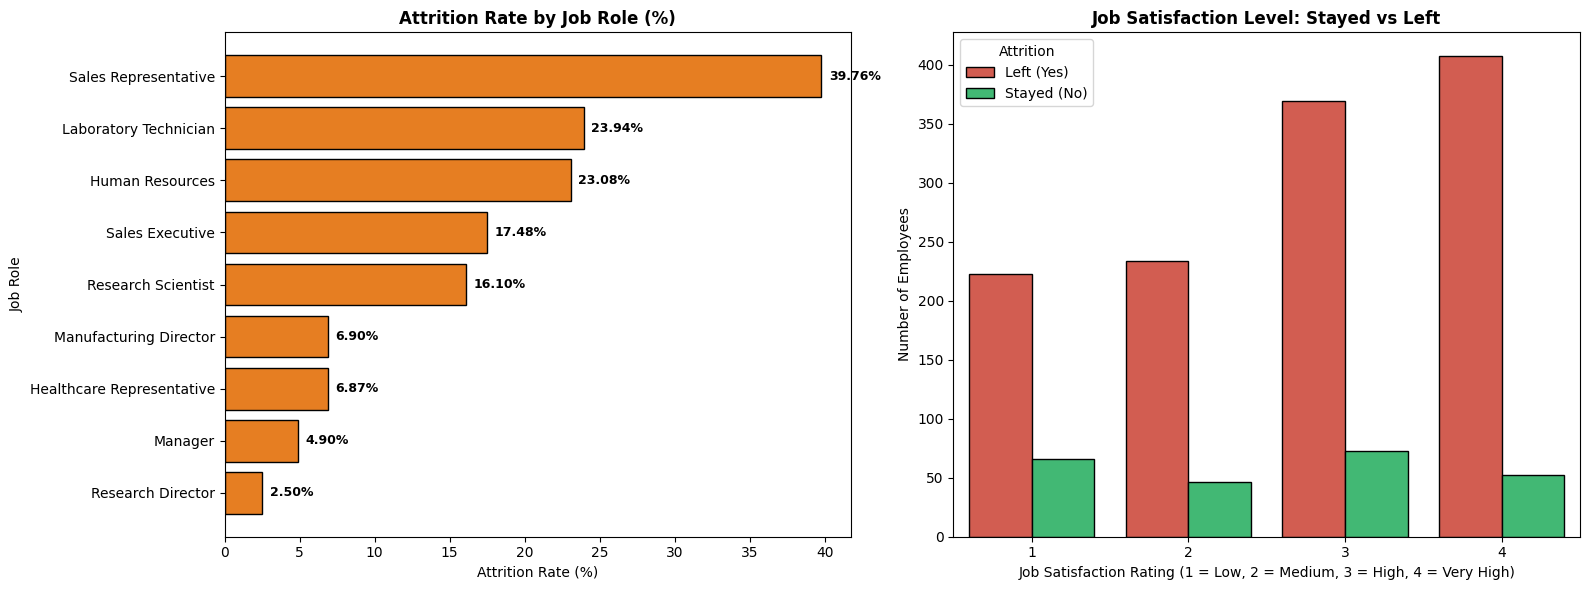

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

role_attrition_sorted = jobrole_attrition.sort_values(ascending=True)

#Charts: 1
bars = axes[0].barh(
    role_attrition_sorted.index,
    role_attrition_sorted.values,
    color='#e67e22',       # Professional Orange color
    edgecolor='black'
)
axes[0].set_title('Attrition Rate by Job Role (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_ylabel('Job Role')

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center', fontweight='bold', fontsize=9)

#Charts: 2
sns.countplot(
    data=df_clean,
    x='JobSatisfaction',
    hue='Attrition',
    palette=['#e74c3c', '#2ecc71'],  # Red for Yes, Green for No
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title('Job Satisfaction Level: Stayed vs Left', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Rating (1 = Low, 2 = Medium, 3 = High, 4 = Very High)')
axes[1].set_ylabel('Number of Employees')
axes[1].legend(title='Attrition', labels=['Left (Yes)', 'Stayed (No)'])

###
plt.tight_layout()
###
plt.savefig('02_jobrole_satisfaction.png', dpi=300, bbox_inches='tight')
print("SUCCESS: Saved '02_jobrole_satisfaction.png' to project folder!")
plt.show()



### Correlation Heatmaps

In [ ]:
# filtering columns for choosing only numeric columns
numeric_df = df_clean.select_dtypes(include=[np.number])
correlation_series = numeric_df.corr()['Attrition_Numeric'].sort_values(ascending=False)

print("TOP FACTORS CORRELATED WITH ATTRITION")
print(correlation_series)

TOP FACTORS CORRELATED WITH ATTRITION
Attrition_Numeric           1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition_Numeric, dtype: float64


In [ ]:
###  Example of above----------------------------------->
# Attrition_Numeric           1.000000   (Self-correlation is always 1.0)
# DistanceFromHome            0.077924   (Positive: Longer commute = slightly higher turnover)
# NumCompaniesWorked          0.043494   (Positive: Job-hoppers leave slightly faster)
# ...
# PercentSalaryHike          -0.013478
# JobSatisfaction            -0.103481   (Negative: Lower satisfaction = higher turnover)
# EnvironmentSatisfaction   -0.103369   (Negative: Bad workplace culture = higher turnover)
# JobInvolvement             -0.130016   (Negative: Disengaged employees leave faster)
# Age                        -0.159205   (Negative: Younger employees leave faster)
# MonthlyIncome              -0.159840   (Negative: Lower pay = higher turnover)
# YearsAtCompany             -0.171063   (Negative: Shorter tenure = higher turnover)
# TotalWorkingYears          -0.171091   (Negative: Less experienced workers leave faster)

SUCCESS: Saved '03_correlation_heatmap.png' to project folder!


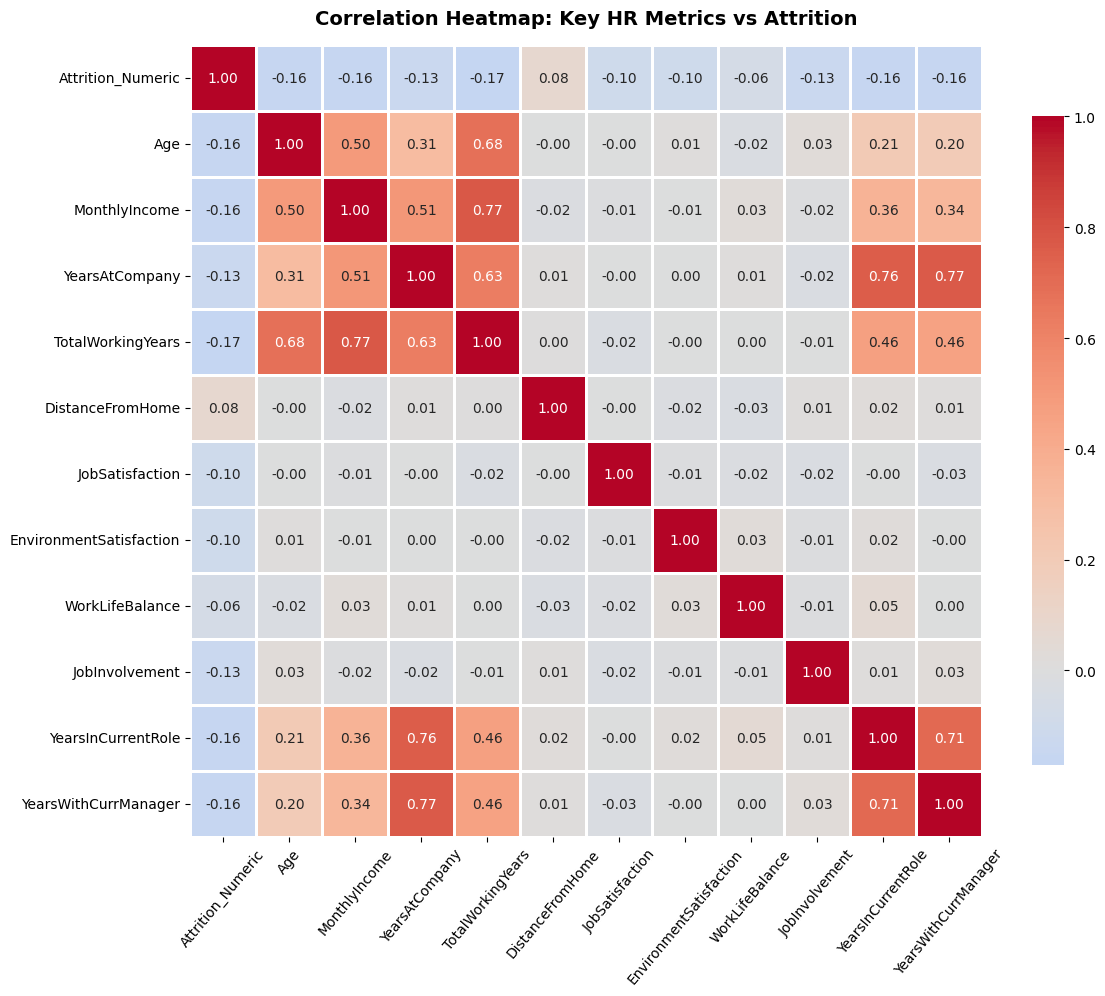

In [ ]:
# For Exact Colums
key_cols = [
    'Attrition_Numeric', 'Age', 'MonthlyIncome', 'YearsAtCompany',
    'TotalWorkingYears', 'DistanceFromHome', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
    'YearsInCurrentRole', 'YearsWithCurrManager'
]

corr_matrix = df_clean[key_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,              # Writes the exact correlation number inside each cell
    fmt='.2f',               # Formats numbers to 2 decimal places (e.g. 0.17)
    cmap='coolwarm',         # Blue for negative, Red for positive
    center=0,                # Centers the neutral white color exactly at 0.0
    square=True,             # Makes every cell a perfect square
    linewidths=1,            # Adds clean white dividing lines between cells
    cbar_kws={"shrink": 0.8} # Adjusts the colorbar size
)
plt.title('Correlation Heatmap: Key HR Metrics vs Attrition', fontsize=14, fontweight='bold', pad=15)
plt.tick_params(axis='x', rotation=50)

###
plt.tight_layout()
###
plt.savefig('03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("SUCCESS: Saved '03_correlation_heatmap.png' to project folder!")
plt.show()



# Risk Score Analysis

In [ ]:
# Creating a Risk Score from (0 to 3 points) based on 3 conditions------------->
### Resetting Every data to zero for setting a conditions
df_clean['Risk_Score'] = 0

### Condition 1:
df_clean.loc[df_clean['OverTime'] == 'Yes', 'Risk_Score'] += 1
### Condition 2:
df_clean.loc[df_clean['JobSatisfaction'] <= 2, 'Risk_Score'] += 1
### Condition 3:
df_clean.loc[df_clean['YearsAtCompany'] <= 2, 'Risk_Score'] += 1

### Calculate the actual Attrition Rate for each Risk Score:
risk_validation = df_clean.groupby('Risk_Score')['Attrition_Numeric'].mean() * 100
risk_validation = risk_validation.round(2)

risk_counts = df_clean['Risk_Score'].value_counts().sort_index()

risk_summary = pd.DataFrame({
    'Total_Employees': risk_counts,
    'Actual_Attrition_Rate_%': risk_validation
})

print("DOES OUR RISK SCORE ACCURATELY PREDICT ATTRITION?")
print(risk_summary)



DOES OUR RISK SCORE ACCURATELY PREDICT ATTRITION?
            Total_Employees  Actual_Attrition_Rate_%
Risk_Score                                          
0                       488                     5.74
1                       676                    14.79
2                       267                    32.21
3                        39                    58.97


### Visualizing Risk Score

SUCCESS: Saved '04_risk_score_validation.png' to project folder!


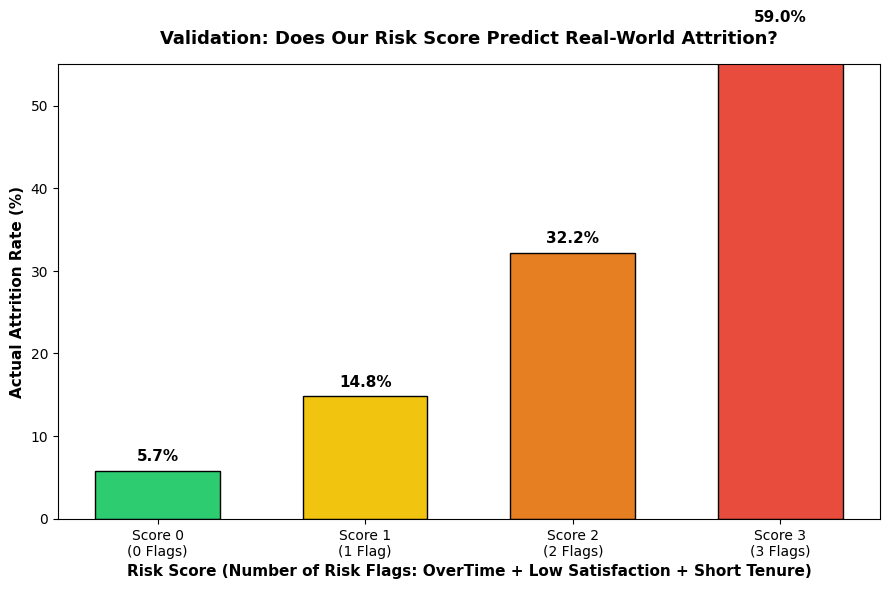

In [ ]:
plt.figure(figsize=(9, 6))

risk_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

bars = plt.bar(
    risk_validation.index,
    risk_validation.values,
    color=risk_colors,
    edgecolor='black',
    width=0.6
)

plt.title('Validation: Does Our Risk Score Predict Real-World Attrition?', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Risk Score (Number of Risk Flags: OverTime + Low Satisfaction + Short Tenure)', fontsize=11, fontweight='bold')
plt.ylabel('Actual Attrition Rate (%)', fontsize=11, fontweight='bold')
plt.xticks(risk_validation.index, ['Score 0\n(0 Flags)', 'Score 1\n(1 Flag)', 'Score 2\n(2 Flags)', 'Score 3\n(3 Flags)'])
plt.ylim(0, 55)  # Set Y-axis limit to give room for text labels

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.2,
        f'{height:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

###
plt.tight_layout()
###
plt.savefig('04_risk_score_validation.png', dpi=300, bbox_inches='tight')
print("SUCCESS: Saved '04_risk_score_validation.png' to project folder!")
plt.show()

# Exporting Files for Power BI

In [ ]:



print("\n" + "=" * 60)
print("EXPORTING DELIVERABLES FOR POWER BI")
print("=" * 60)


# 1. Export Department Attrition Summary
dept_attrition.to_csv('dept_attrition_python.csv', header=['Attrition_Rate_Percent'])
print("1. Saved: 'dept_attrition_python.csv'")

# 2. Export the Risk Score Validation Table
risk_validation.to_csv('risk_score_validation.csv', header=['Attrition_Rate_Percent'])
print("2. Saved: 'risk_score_validation.csv'")

# 3. Export Full Clean Dataset WITH the Risk_Score Column
df_clean.to_csv('hr_data_with_risk_score.csv', index=False)
print("3. Saved: 'hr_data_with_risk_score.csv'")

# 4. Export Actionable Watch-List of Currently Employed At-Risk Staff (Score >= 2)
# Condition: Currently employed (Attrition == 'No') AND Risk_Score >= 2
watchlist = df_clean[(df_clean['Attrition'] == 'No') & (df_clean['Risk_Score'] >= 2)]
watchlist = watchlist.sort_values(by='Risk_Score', ascending=False)

watchlist_columns = [
    'Department', 'JobRole', 'Age', 'MonthlyIncome',
    'YearsAtCompany', 'OverTime', 'JobSatisfaction', 'Risk_Score'
]
watchlist_export = watchlist[watchlist_columns]

# Export to CSV
watchlist_export.to_csv('watchlist_from_python.csv', index=False)
print(f"4. Saved: 'watchlist_from_python.csv' ({len(watchlist_export)} active at-risk employees identified)")


EXPORTING DELIVERABLES FOR POWER BI
1. Saved: 'dept_attrition_python.csv'
2. Saved: 'risk_score_validation.csv'
3. Saved: 'hr_data_with_risk_score.csv'
4. Saved: 'watchlist_from_python.csv' (197 active at-risk employees identified)
